#### Инициализация

In [1]:
import numpy as np
import h5py
import importlib

from gtda.plotting import plot_point_cloud
from pathlib import Path

#### Визуализация

In [14]:
samples = {}
train_file = "./data/MNIST3d/train_point_clouds.h5"
test_file = "./data/MNIST3d/test_point_clouds.h5"

with h5py.File(train_file,"r") as hf:
  for key in hf.keys(): # key = id
    group = hf[key]
    label = int(group.attrs["label"])

    if (label not in samples):  # take 1 instance of each digit
      points = group["points"][:] # (N, 3)  x, y, z
      samples[label] = points

      if len(samples) == 10:
        break


In [3]:
sorted_samples = dict(sorted(samples.items()))
plot_point_cloud(sorted_samples[8]) # change number in brackets to plot different digits

Точки в облаках расположены достаточно плотно. Внутри цифры полые.

#### Нормализация
Согласно документации датасета, все облака точек должны быть нормализованы. Проверим это, собрав статистику по каждой цифре отдельно и по всем цифрам сразу.

In [15]:
import utils.stat
importlib.reload(utils.stat)

class_stats, global_stats = utils.stat.compute_statistics(test_file)

In [16]:
class_stats

num_points                                      range_x      range_y  \
      num_clouds        mean        std    min    max    mean  std    mean   
label                                                                        
0             85  26769.4118  2644.7173  20050  31700     0.3  0.0  0.8635   
1            126  12088.4921  1464.4612   9700  17050     0.3  0.0  0.3508   
2            116  24622.8448  3005.2085  17900  31250     0.3  0.0  0.8966   
3            107  24294.8598  3658.3900  15650  33200     0.3  0.0  0.7836   
4            110  21094.5455  2503.8901  14900  27600     0.3  0.0  0.7795   
5             87  24521.8391  3213.0611  16600  32200     0.3  0.0  0.8684   
6             87  23444.8276  3007.9936  17250  30250     0.3  0.0  0.7684   
7             99  19495.9596  2817.1910  13100  28000     0.3  0.0  0.7803   
8             89  25527.5281  3215.3928  19200  34800     0.3  0.0  0.7545   
9             94  21281.3830  2572.0999  15100  28950     0.3  0.0  0.7000   

              range_z          
          std    mean     std  
label                          
0      0.1348  0.9753  0.0714  
1      0.1365  1.0000  0.0000  
2      0.1128  0.9871  0.0407  
3      0.1531  0.9930  0.0318  
4      0.1434  0.9936  0.0339  
5      0.1213  0.9816  0.0596  
6      0.1390  0.9983  0.0161  
7      0.1584  0.9980  0.0122  
8      0.1289  0.9972  0.0190  
9      0.1040  1.0000  0.0000

Наиболее заметное различие наблюдается в количестве точек: цифры 0 и 8 представлены наиболее плотными облаками, в то время как цифра 1 содержит существенно меньше точек.
По пространственным характеристикам все объекты имеют практически идентичный диапазон по оси X, что обусловлено особенностями генерации датасета. В то же время по осям Y и Z наблюдаются выраженные класс-специфичные различия. Цифра 1 характеризуется вытянутостью (относительно узкий диапазон по Y), в то время как цифры 0, 2 и 5 имеют более сбалансированные пропорции. Классы демонстрируют диапазон по Z близкий к 1.0.

In [17]:
global_stats

,mean,std,min,max
num_points,21950.3500,5124.8182,9700.00,34800.0
range_x,0.3000,0.0000,0.30,0.3
range_y,0.7438,0.2082,0.20,1.0
range_z,0.9928,0.0359,0.65,1.0
label,4.3270,2.8401,0.00,9.0


#### Сэмплирование

In [18]:
import utils.subsampling
importlib.reload(utils.subsampling)

<module 'utils.subsampling' from 'c:\\Users\\kiril\\OneDrive\\Documents\\Projects\\topology-mnist3d\\utils\\subsampling.py'>

In [19]:
point_clouds, labels = utils.subsampling.subsample_dataset(train_file, max_samples_per_class=550)

In [20]:
test_point_clouds, test_labels = utils.subsampling.subsample_dataset(test_file, max_samples_per_class=200)

Облака содержат очень много точек. Симплициальные комплексы долго считаются и могут не влезать в память. Попробуем сэмплировать точки.

In [10]:
import utils.subsampling
importlib.reload(utils.subsampling)

to_subsample, labels_subsampled = utils.subsampling.subsample_dataset(train_file, max_samples_per_class=100)
subsampled_point_clouds = utils.subsampling.subsample_point_clouds(to_subsample, 5000)

plot_point_cloud(subsampled_point_clouds[0])

#### Симплициальные комплексы и диаграммы персистентности

##### Альфа комплекс

Альфа-комплекс представляет собой симплициальный комплекс, предназначенный для анализа топологической структуры облаков точек. Его построение основано на геометрическом расположении точек в пространстве и позволяет выявлять связные компоненты, циклы и полости, сохраняя при этом форму исходного объекта.

Альфа-комплекс использует информацию о взаимном расположении точек и формируется на основе триангуляции Делоне. Благодаря этому в комплекс включаются только геометрически обоснованные элементы, что существенно снижает их общее количество и уменьшает вычислительную сложность.

По мере увеличения параметра фильтрации альфа-комплекс постепенно расширяется: отдельные точки объединяются в связные компоненты, возникают и исчезают циклы, а также могут формироваться трёхмерные полости. Наблюдение за изменением топологических характеристик на различных уровнях фильтрации позволяет определить наиболее устойчивые особенности объекта и отделить значимые структуры от шумовых артефактов.

Для облаков точек, представляющих трёхмерные изображения цифр, альфа-комплекс позволяет эффективно сохранять информацию о форме объектов и выявлять различия между классами, связанные с наличием отверстий, замкнутых контуров и особенностями пространственной геометрии.

In [11]:
import utils.persistence
importlib.reload(utils.persistence)

_, diagrams = utils.persistence.build_diagrams(point_clouds, n_jobs=-1)

Processing clouds: 100%|██████████| 4987/4987 [29:29<00:00,  2.82it/s]


In [12]:
import utils.persistence
importlib.reload(utils.persistence)

_, test_diagrams = utils.persistence.build_diagrams(test_point_clouds, n_jobs=-1)

Processing clouds: 100%|██████████| 1000/1000 [09:40<00:00,  1.72it/s]


##### Сохранение и загрузка диаграмм

In [3]:
trees_path = Path("./data/tda/simplex_trees_gudhi.pkl")
diagrams_path = Path("./data/tda/persistence_diagrams_gudhi.pkl")

test_trees_path = Path("./data/tda/test_simplex_trees_gudhi.pkl")
test_diagrams_path = Path("./data/tda/test_persistence_diagrams_gudhi.pkl")

In [14]:
import utils.save_load
importlib.reload(utils.save_load)

utils.save_load.save_tree_diagram(diagrams_path, diagrams)
utils.save_load.save_tree_diagram(test_diagrams_path, test_diagrams)

Diagrams saved to data\tda\persistence_diagrams_gudhi.pkl
Diagrams saved to data\tda\test_persistence_diagrams_gudhi.pkl


In [4]:
import utils.save_load
importlib.reload(utils.save_load)

diagrams = utils.save_load.load_object(diagrams_path)
test_diagrams = utils.save_load.load_object(test_diagrams_path)

Loaded 4987 objects
Loaded 1000 objects


##### Отрисовка диаграмм

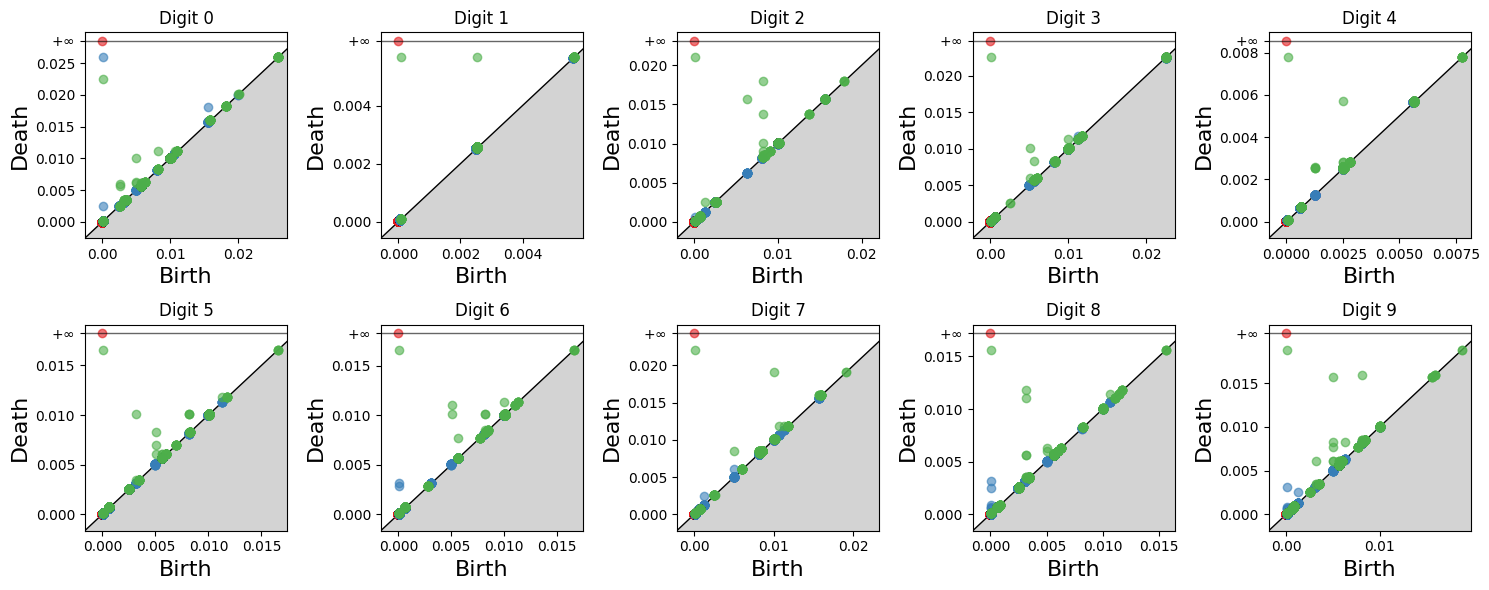

In [15]:
import utils.plot
importlib.reload(utils.plot)

utils.plot.plot_all_digits(diagrams, labels)

##### Диаграммы по классам

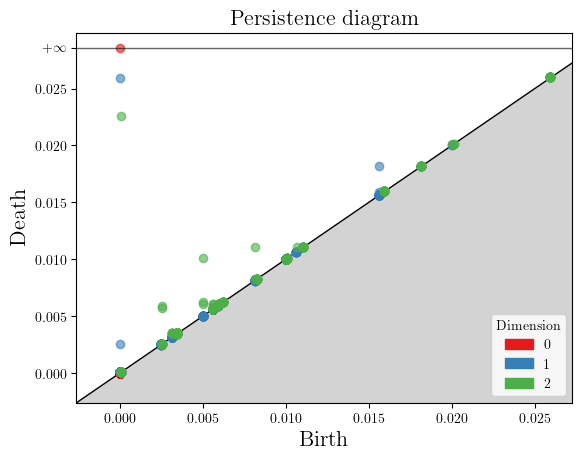

In [16]:
import utils.plot
importlib.reload(utils.plot)

digit = 0
utils.plot.plot_persistence(diagrams, labels, digit)

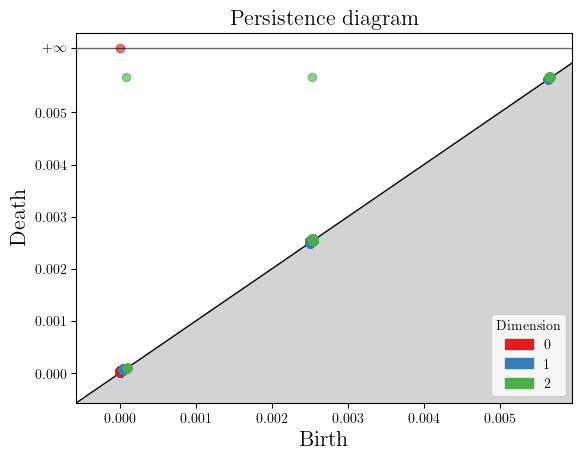

In [17]:
import utils.plot
importlib.reload(utils.plot)

digit = 1

utils.plot.plot_persistence(diagrams, labels, digit)

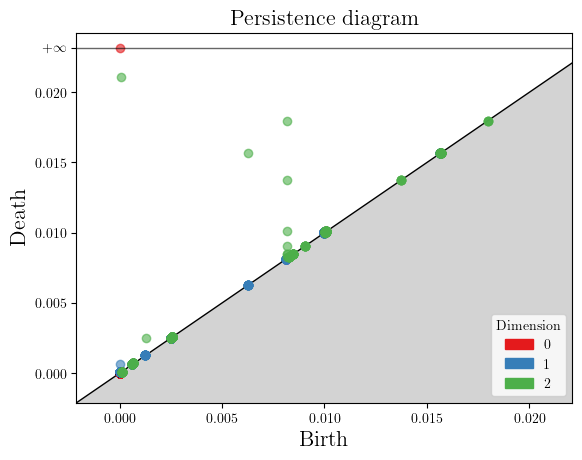

In [18]:
import utils.plot
importlib.reload(utils.plot)

digit = 2

utils.plot.plot_persistence(diagrams, labels, digit)

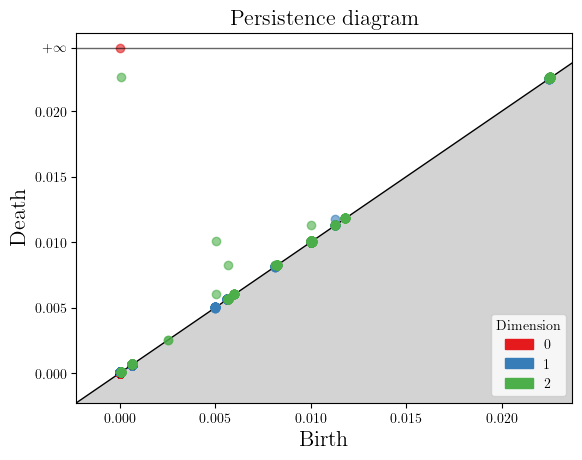

In [19]:
import utils.plot
importlib.reload(utils.plot)

digit = 3

utils.plot.plot_persistence(diagrams, labels, digit)

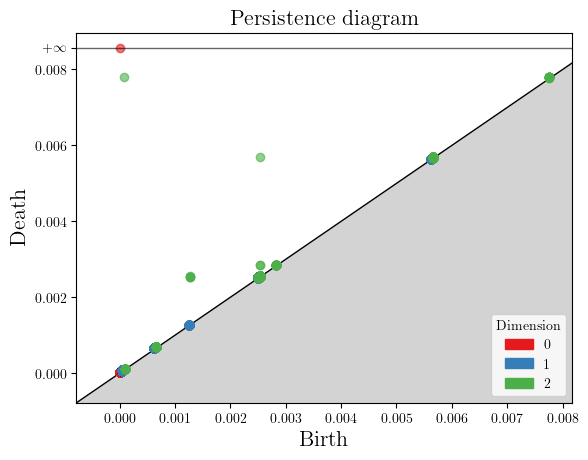

In [20]:
import utils.plot
importlib.reload(utils.plot)

digit = 4

utils.plot.plot_persistence(diagrams, labels, digit)

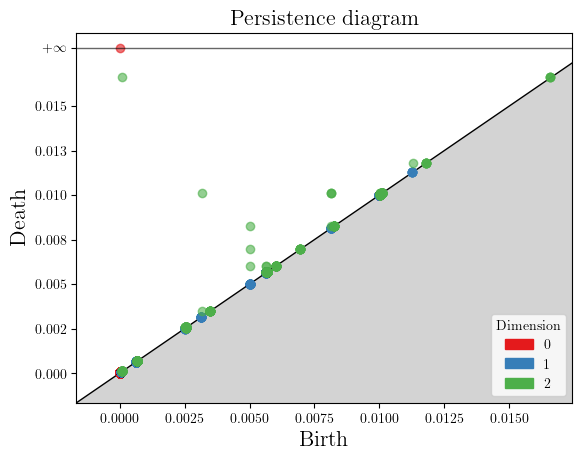

In [21]:
import utils.plot
importlib.reload(utils.plot)

digit = 5

utils.plot.plot_persistence(diagrams, labels, digit)

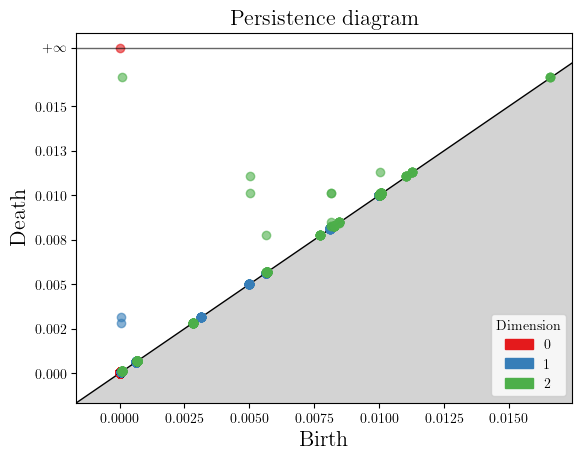

In [22]:
import utils.plot
importlib.reload(utils.plot)

digit = 6

utils.plot.plot_persistence(diagrams, labels, digit)

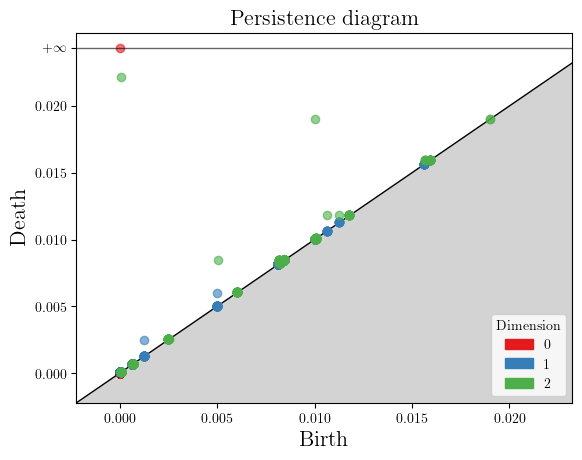

In [23]:
import utils.plot
importlib.reload(utils.plot)

digit = 7

utils.plot.plot_persistence(diagrams, labels, digit)

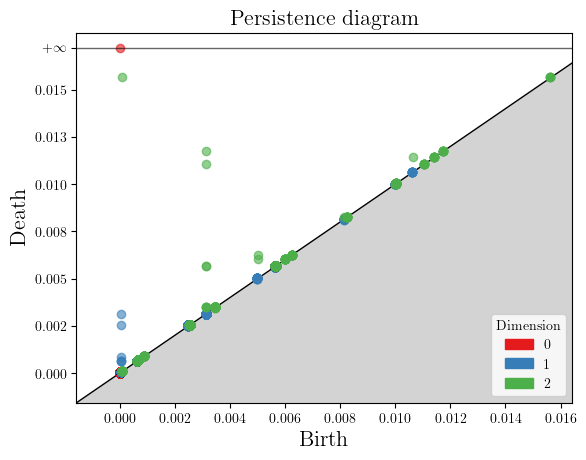

In [24]:
import utils.plot
importlib.reload(utils.plot)

digit = 8

utils.plot.plot_persistence(diagrams, labels, digit)

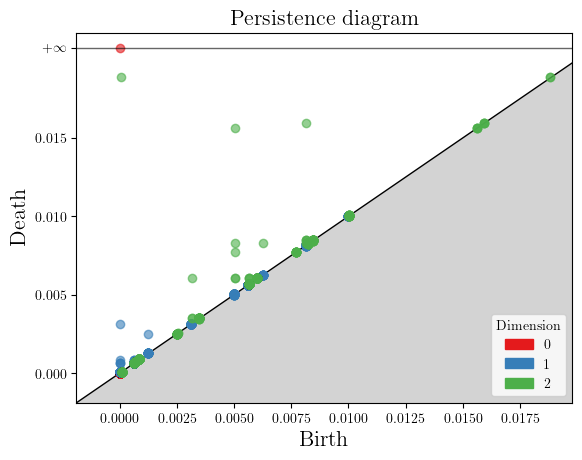

In [25]:
import utils.plot
importlib.reload(utils.plot)

digit = 9

utils.plot.plot_persistence(diagrams, labels, digit)

#### Векторизация

После построения диаграмм персистентности возникает задача их использования в алгоритмах машинного обучения. Диаграммы не могут быть напрямую поданы на вход большинству методов классификации и регрессии. Для решения этой проблемы применяются методы векторизации, преобразующие диаграмму персистентности в вектор фиксированной длины.

Одним из наиболее распространённых способов векторизации являются ландшафты персистентности (Persistence Landscapes). Для каждой точки диаграммы строится функция, отражающая время существования соответствующего топологического признака. Затем для каждого значения параметра фильтрации выбираются наибольшие значения этих функций, образующие набор уровней ландшафта. Полученные функции дискретизируются на равномерной сетке и преобразуются в числовой вектор фиксированной размерности.

In [5]:
import numpy as np

from joblib import Parallel, delayed
from tqdm_joblib  import tqdm_joblib 


def convert_diagram(diag):
    n = len(diag)

    arr = np.empty((n, 3), dtype=np.float64)

    for i, (dim, (birth, death)) in enumerate(diag):
        arr[i, 0] = birth
        arr[i, 1] = death
        arr[i, 2] = dim

    return arr

c:\Users\kiril\OneDrive\Documents\Projects\topology-mnist3d\.venv\Lib\site-packages\tqdm_joblib\__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [6]:
with tqdm_joblib (
    desc="Converting diagrams",
    total=len(diagrams)
):
    diagrams_sub_gtda = Parallel(
        n_jobs=-1,
        backend="loky"
    )(
        delayed(convert_diagram)(diag)
        for diag in diagrams
    )

with tqdm_joblib (
    desc="Converting diagrams",
    total=len(test_diagrams)
):
    test_diagrams_gtda = Parallel(
        n_jobs=-1,
        backend="loky"
    )(
        delayed(convert_diagram)(diag)
        for diag in test_diagrams
    )

Converting diagrams:   0%|          | 0/4987 [00:00<?, ?it/s]

Converting diagrams:   0%|          | 0/1000 [00:00<?, ?it/s]

In [7]:
def top_k(diag, k=50):
    """
    Принимает диаграмму персистентности и оставляет k лучших (наиболее далеких от диагонали) точек.
    """
    pers = diag[:, 1] - diag[:, 0]  # death - birth
    idx = np.argsort(pers)[::-1][:k]    # индексы самых устойчивых объектов
    return diag[idx]

In [8]:
X_h1_top = [top_k(d[d[:, 2] == 1], k=50)    # только h1
            for d in diagrams_sub_gtda]

X = np.stack(X_h1_top)

X_test_h1_top = [top_k(d[d[:, 2] == 1], k=50)    # только h1
            for d in test_diagrams_gtda]

X_test = np.stack(X_test_h1_top)

Параметр n_layers определяет количество уровней ландшафта, используемых для описания диаграммы персистентности. Первый уровень отражает наиболее выраженные топологические признаки, а последующие уровни учитывают менее значимые структуры, позволяя сохранить больше информации о форме объекта. Параметр n_bins задаёт число точек дискретизации по оси фильтрации, то есть разрешение, с которым непрерывные функции ландшафта преобразуются в числовое представление. Увеличение n_bins позволяет более точно описывать форму ландшафта, однако приводит к росту размерности признакового пространства и вычислительных затрат.

In [9]:
from gtda.diagrams import PersistenceLandscape

PL = PersistenceLandscape(n_layers=3, n_bins=500, n_jobs=-1)
landscapes = PL.fit_transform(X)
test_landscapes = PL.transform(X_test)

c:\Users\kiril\OneDrive\Documents\Projects\topology-mnist3d\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\kiril\OneDrive\Documents\Projects\topology-mnist3d\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\kiril\OneDrive\Documents\Projects\topology-mnist3d\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [21]:
idx = np.where(labels == 0)[0][0]
PL.plot(landscapes, sample=idx)

#### Классификация

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

import ml.optuna_search
importlib.reload(ml.optuna_search)

<module 'ml.optuna_search' from 'c:\\Users\\kiril\\OneDrive\\Documents\\Projects\\topology-mnist3d\\ml\\optuna_search.py'>

In [23]:
y_train = labels
y_test = test_labels

X_train = np.reshape(landscapes, (y_train.shape[0],-1))
print(X_train.shape)

X_test_squeezed = np.reshape(test_landscapes, (y_test.shape[0],-1))
print(X_test_squeezed.shape)

X_val, X_test, y_val, y_test = train_test_split(X_test_squeezed, y_test, test_size=0.5, random_state=42, stratify=y_test)

(4987, 1500)
(1000, 1500)


In [25]:
model_list = ["XGBClassifier"]

search = ml.optuna_search.ModelOptimization(model_list)
search.fit(X_train, y_train, X_val, y_val, X_test, y_test, n_trials=5, n_startup_trials=5)

clf = search.best_models[0]


XGBClassifier hyperoptimization


  0%|          | 0/5 [00:00<?, ?it/s]

Accuracy =  0.454
F1 score =  0.4365497745501526
              precision    recall  f1-score   support

           0       0.74      0.76      0.75        42
           1       0.43      1.00      0.60        63
           2       0.31      0.17      0.22        58
           3       0.45      0.34      0.39        53
           4       0.38      0.27      0.32        55
           5       0.26      0.16      0.20        44
           6       0.61      0.45      0.52        44
           7       0.20      0.16      0.18        50
           8       0.83      0.68      0.75        44
           9       0.39      0.51      0.44        47

    accuracy                           0.45       500
   macro avg       0.46      0.45      0.44       500
weighted avg       0.45      0.45      0.43       500

[[32  0  1  0  0  3  0  0  0  6]
 [ 0 63  0  0  0  0  0  0  0  0]
 [ 0  9 10  7  8  2  2 14  0  6]
 [ 0  7  5 18  5  9  1  5  2  1]
 [ 0 20  4  5 15  2  1  5  0  3]
 [ 1 13  4  4  6  7  1  6  

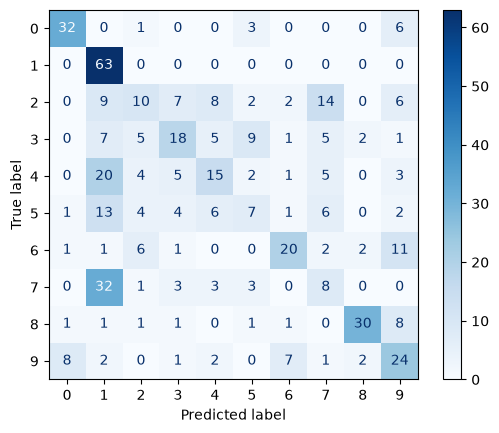

In [26]:
y_test_pred = clf.predict(X_test)

print("Accuracy = ", accuracy_score(y_test, y_test_pred))
print("F1 score = ", f1_score(y_test, y_test_pred, average="macro"))
print(classification_report(y_test,y_test_pred))

disp = ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, cmap=plt.cm.Blues)
print(disp.confusion_matrix)
	
plt.show()

In [27]:
import pickle
from pathlib import Path

model_path = Path("./ml/models/alpha/XGB.pkl")

with open (model_path,'wb') as f:
    pickle.dump(clf, f)

In [ ]:
import pickle
from pathlib import Path

model_path = Path("./ml/models/alpha/XGB.pkl")

with open (model_path,'rb') as f:
    clf = pickle.load(f)